# (21) Retina+V1: Kyoto color

host: ```yoru```, device: ```cuda:0```

**motivation:** <br>

Kyoto16-col

two layers:
- Retina (Gaussian + Logistic)
- V1 (Poisson)

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-25/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-25/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-25/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_RetinaV1'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from main.config import Config


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Fit

In [3]:
cfg_layers = [
    CFG_CLASSES['gaus'](t_repeats=1, beta_outer=32.0, n_latents=256, latent_act='logistic'),
    CFG_CLASSES['pois'](t_repeats=1, beta_outer=64.0, n_latents=1024),
]
cfg = Config(
    dataset='Kyoto16-col',
    cfg_layers=cfg_layers,
    t_train=64,
    t_warmup=32,
)

In [4]:
tr = Trainer(
    model=RetinaV1(cfg),
    cfg=ConfigTrain(epochs=500),
    device=device,
)
tr.n_iters

153500

In [5]:
tr.model.print()

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|   RetinaV1  |  988.2 K   |
|     ———     |    ———     |
|  layers.g0  |  198.9 K   |
|  layers.p1  |  789.2 K   |
+-------------+------------+

In [6]:
print(tr.model)

RetinaV1(
  (layers): ModuleDict(
    (g0): GaussianLogisticLayer(input_dim=768, latent_dim=256, temperature=1, beta_inner=1, eps=1)
    (p1): PoissonLayer(input_dim=768, latent_dim=1024, temperature=1, beta_inner=1, eps=1)
  )
)

In [7]:
tr.print()

Kyoto16-col_m(g0+logi,p1)_t(32+64×(1,1))_b(32,64)_k(256,1024)
b200-ep500-lr(0.002)_temp(0.01:0.5)_gr(1000)_(2025_04_24,15:27)

In [8]:
# cm = ''
# fit_name = f"{cm}_{tr.cfg.name()}"
# tr.train(fit_name)

tr.train()

epoch # 500, avg loss: 139.618: 100%|█████| 500/500 [28:39:47<00:00, 206.38s/it]


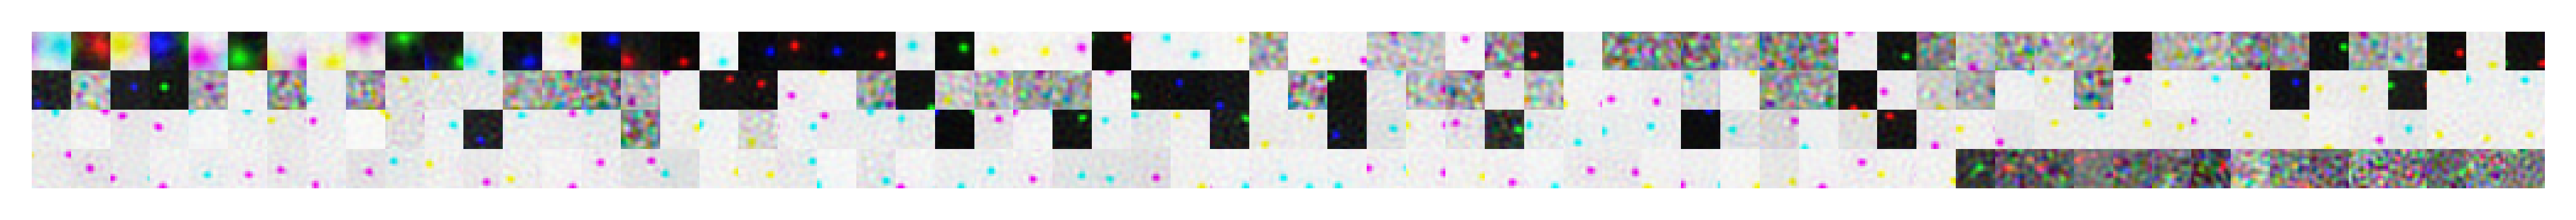

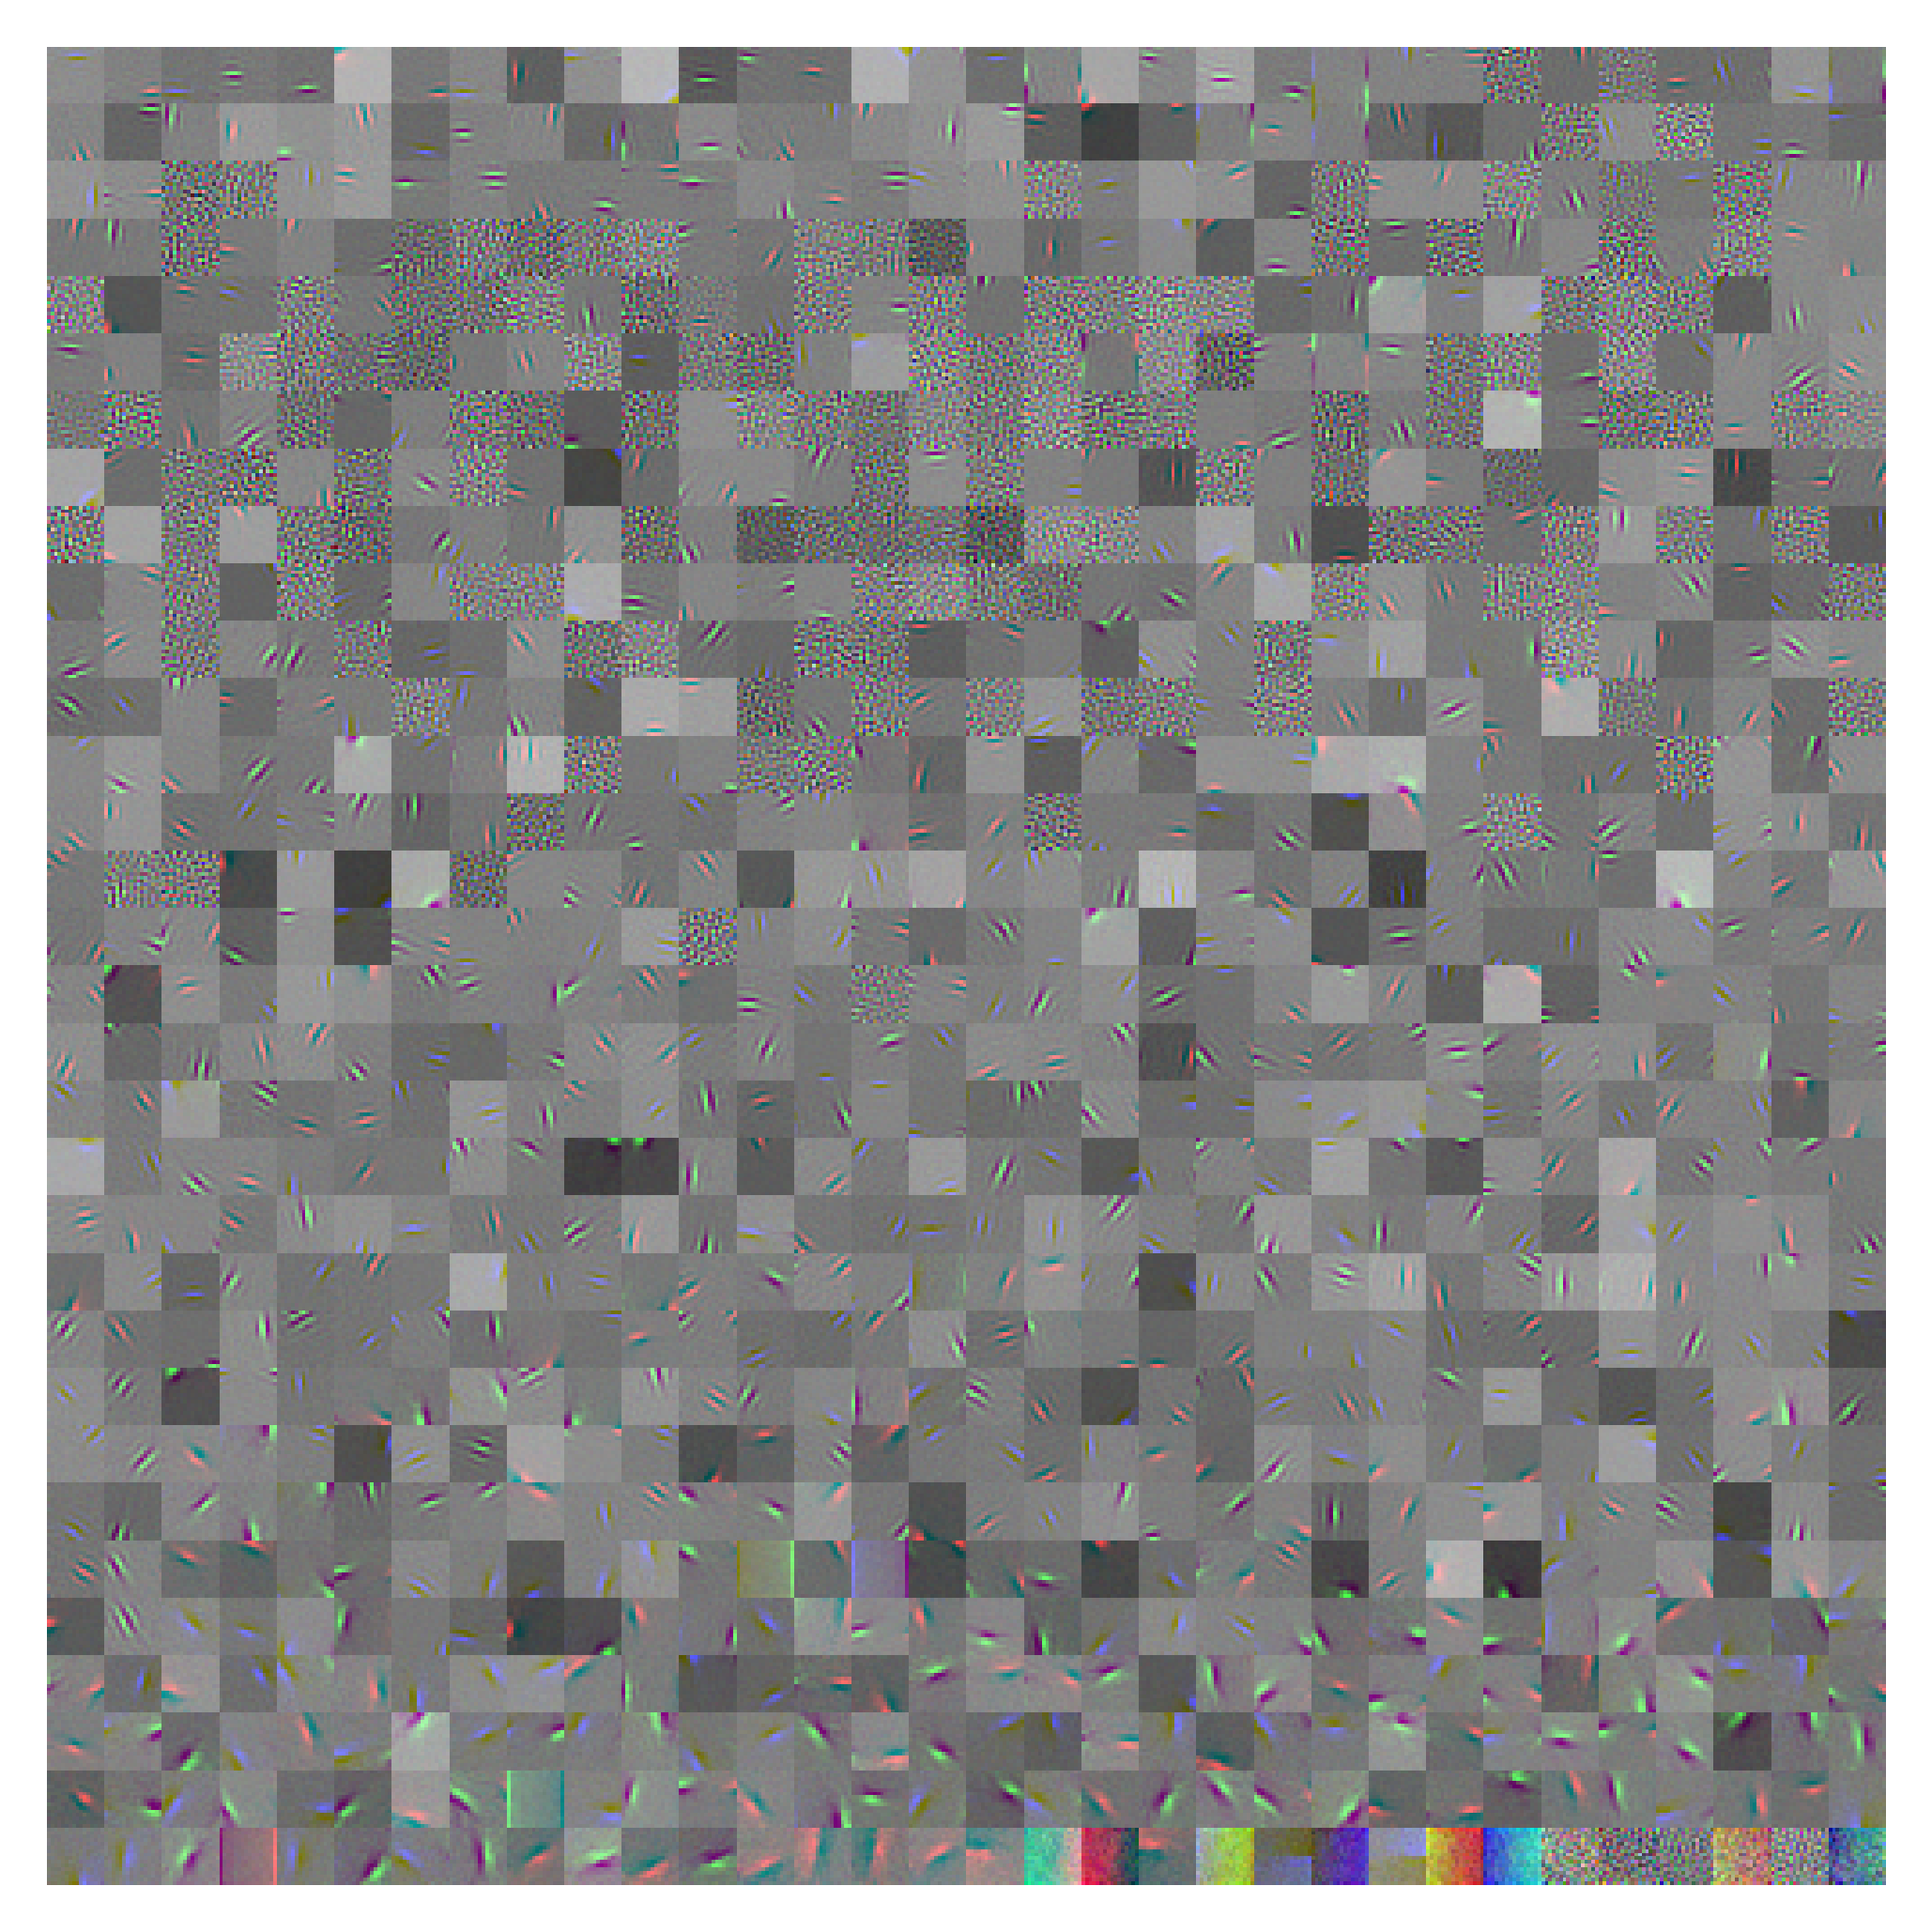

In [9]:
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
for i, (k, v) in enumerate(u0.items()):
    kws = dict(
        order=np.argsort(v),
        nrows=4 if i == 0 else 32, # max(1, tr.model.cfg.n_latents[i] // 32),
        method='min-max',
        dpi=500,
    )
    tr.model.show(k, **kws);

In [10]:
print({
    k: [llr.exp().item() for llr in lay.log_lr]
    for k, lay in tr.model.layers.items()
})

{'g0': [0.06650348752737045, 0.027355371043086052], 'p1': [0.09646295011043549]}

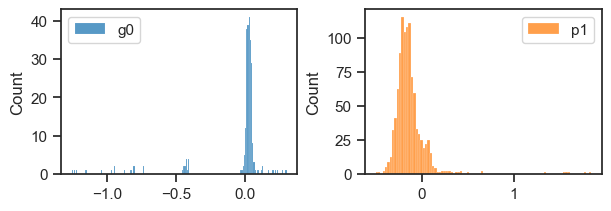

In [11]:
fig, axes = create_figure(1, 2)
for i, (name, x2p) in enumerate(u0.items()):
    sns.histplot(x2p, color=f"C{i}", label=name, ax=axes[i])
add_legend(axes)
plt.show()

In [12]:
shape = (-1, *tr.model.cfg.input_sz)
w = {
    name: tonp(layer.get_weight().T.reshape(shape))
    for name, layer in tr.model.layers.items()
}

# order
u0 = {
    k: tonp(layer.u_init[0].squeeze()) for
    k, layer in tr.model.layers.items()
}
w = {
    k: v[np.argsort(u0[k])]
    for k, v in w.items()
}

print({k: v.shape for k, v in w.items()})

{'g0': (256, 3, 16, 16), 'p1': (1024, 3, 16, 16)}

In [13]:
w['p1'].shape

(1024, 3, 16, 16)

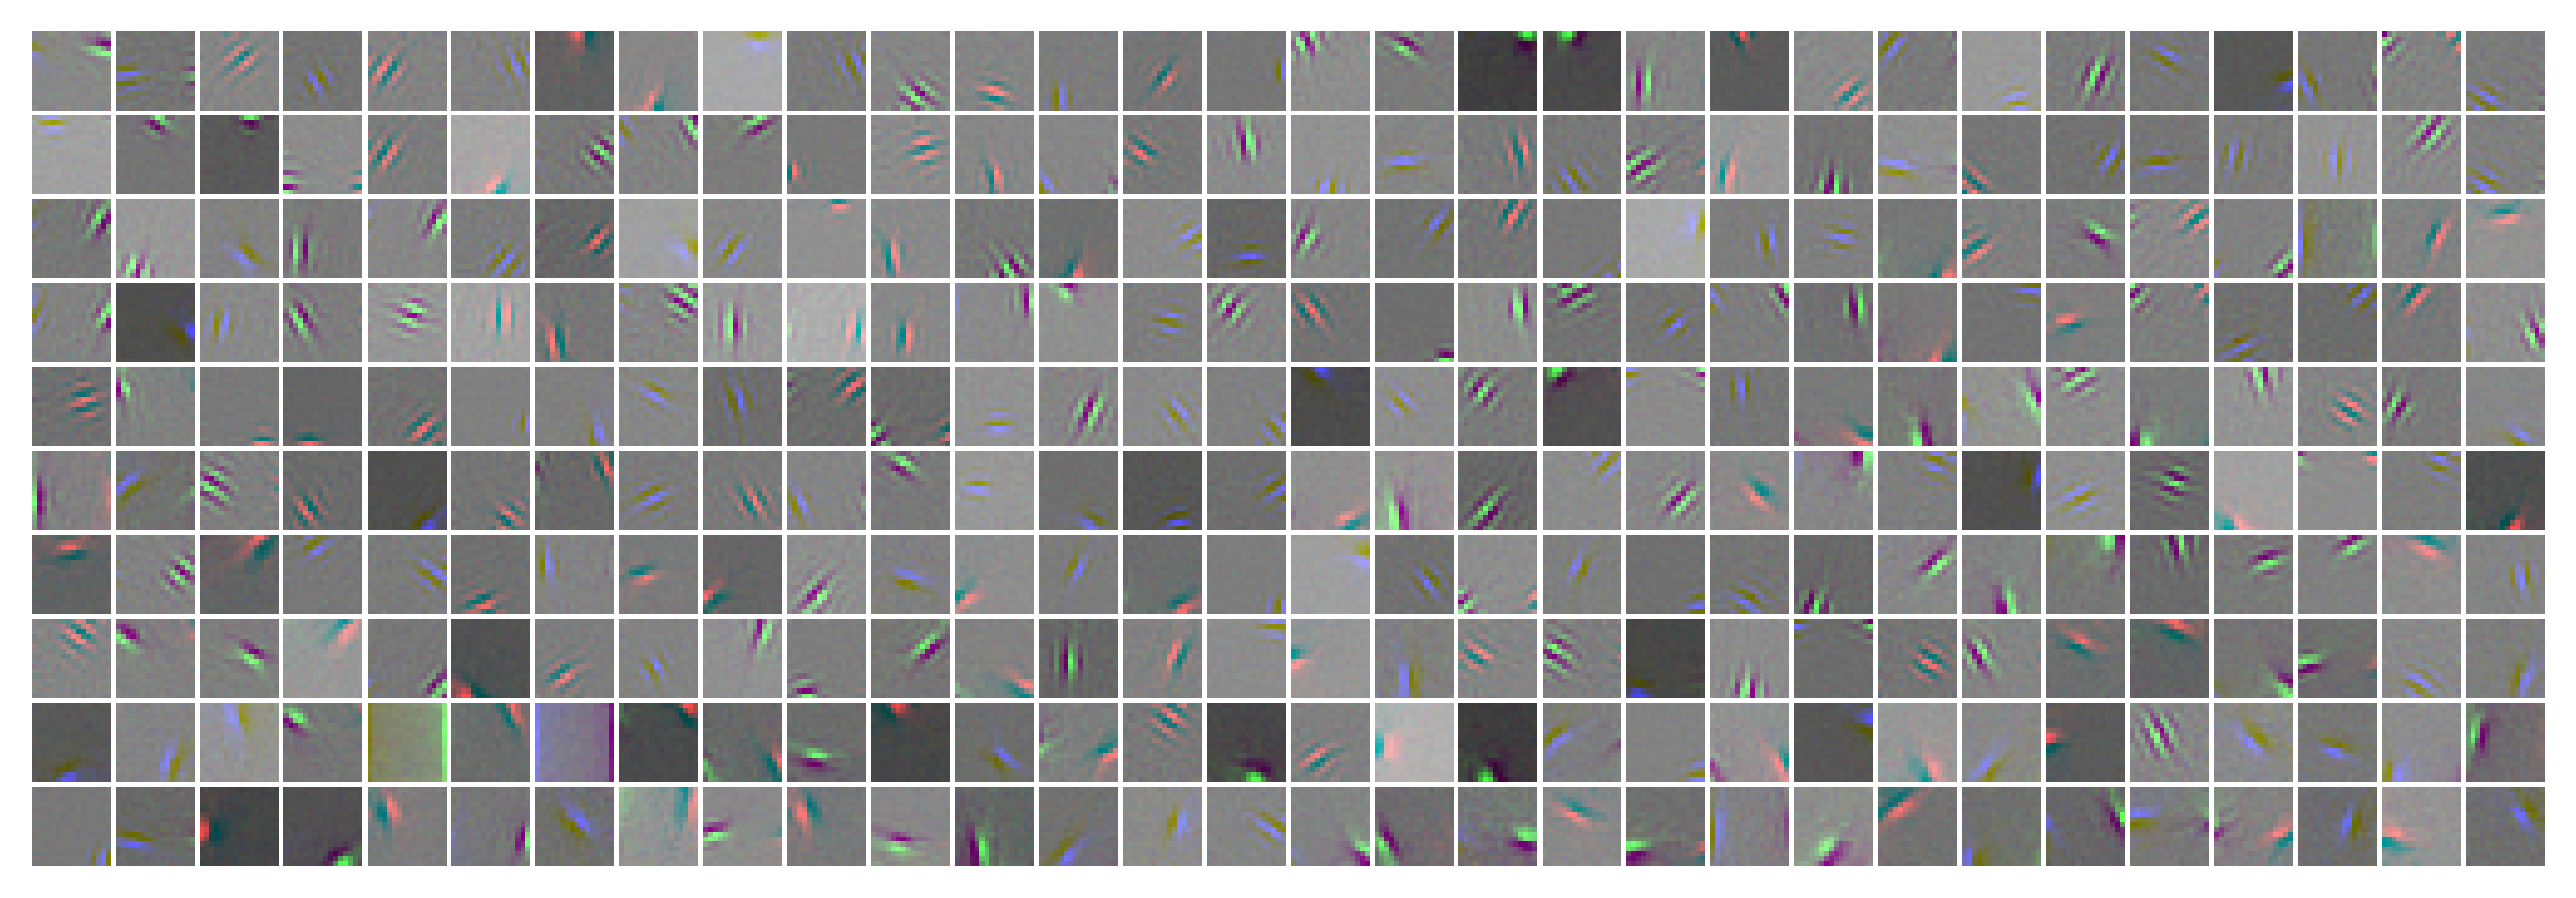

In [16]:
start = 600
num = 300
selected_ids = np.arange(start, start + num)
plot_weights(w['p1'][selected_ids], nrows=10, dpi=1000, method='min-max');

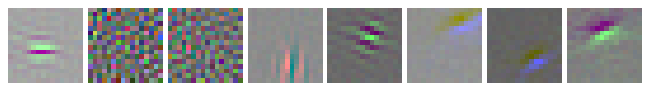

In [17]:
selected_ids = [20, 104, 134, 347, 775, 904, 908, 914]
plot_weights(w['p1'][selected_ids], nrows=1, dpi=80);

In [18]:
def normalize_centered(img):
    max_val = max(abs(np.min(img)), abs(np.max(img)))
    img_normalized = (img / (2 * max_val)) + 0.5  # Rescale to [0, 1]
    return img_normalized

In [19]:
x2p = w['p1'][selected_ids[4]].copy()
x2p = np.transpose(x2p, (1, 2, 0))
x2p = normalize_centered(x2p)
x2p.shape

(16, 16, 3)

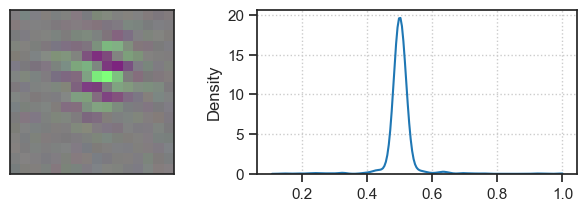

In [20]:
fig, axes = create_figure(1, 2, width_ratios=[1, 1.5])
axes[0].imshow(x2p)
sns.kdeplot(x2p.ravel(), clip=(0, 1), ax=axes[1])
remove_ticks(axes[0], False)
axes[1].grid()
plt.show()

In [22]:
np.linalg.norm((x2p * 2) - 1, axis=(0, 1))

array([0.39037913, 2.5468383 , 0.37744302], dtype=float32)

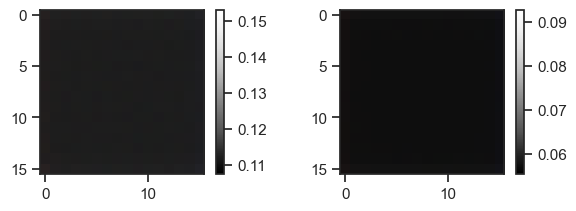

In [23]:
var = {}
for name, layer in tr.model.layers.items():
    log_sigma = layer.get_dec_log_sigma()
    variance = tonp(torch.exp(log_sigma * 2).squeeze())
    variance = variance.reshape(tr.model.cfg.input_sz)
    variance = np.transpose(variance, (1, 2, 0))
    var[name] = variance

fig, axes = create_figure(1, len(var))

for i, (name, x2p) in enumerate(var.items()):
    im = axes[i].imshow(var[name], cmap='Greys_r')
    plt.colorbar(im, ax=axes[i])

plt.show()

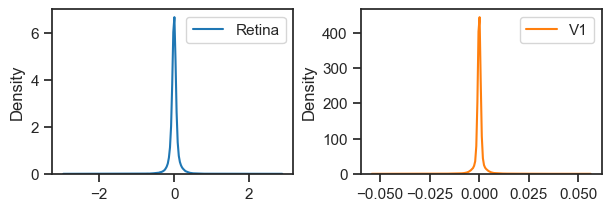

In [32]:
fig, axes = create_figure(1, 2)

sns.kdeplot(tonp(tr.model.layers['g0'].get_weight().ravel()), color='C0', label='Retina', ax=axes[0])
sns.kdeplot(tonp(tr.model.layers['p1'].get_weight().ravel()), color='C1', label='V1', ax=axes[1])

add_legend(axes)
plt.show()

In [33]:
tr.cfg.batch_size = 2000
tr.setup_data()

In [34]:
%%time


items = ['mse', 'r2', 'u', 'samples']

t_total = 1000

r2 = {k: np_nans(t_total) for k in tr.model.layers}
mse = {k: np_nans(t_total) for k in tr.model.layers}

true = []
pred = collections.defaultdict(list)
error = collections.defaultdict(list)

state = collections.defaultdict(list)
samples = collections.defaultdict(list)

for x, *_ in tqdm(iter(tr.dl_vld)):
    tr.model.reset_inference_state(len(x))
    feeder = tr.get_feeder(tr.to(x))
    for t in range(t_total):
        tr.model.update_time(t)
        inpt = feeder[t]
        extras = tr.model.xtract_ftr(
            inpt, return_extras=items)[-1]
        for k, d in extras.items():
            r2[k][t] = d['r2'].mean(0).item()
            mse[k][t] = d['mse'].mean(0).item()

        if (t + 1) == t_total:
            true.append(inpt.flatten(start_dim=1))
            for k, layer in tr.model.layers.items():
                pred[k].append(layer.conditional.loc)
                state[k].append(extras[k]['u'])
                samples[k].append(extras[k]['samples'])
                error[k].append(extras[k]['error'])

torch.cuda.empty_cache()
import gc
gc.collect()

true = torch.cat(true)
pred = {k: torch.cat(v) for k, v in pred.items()}
error = {k: torch.cat(v) for k, v in error.items()}
state = {k: torch.cat(v) for k, v in state.items()}
samples = {k: torch.cat(v) for k, v in samples.items()}

100%|█████████████████████████████████████████████| 8/8 [00:36<00:00,  4.57s/it]


CPU times: user 36.8 s, sys: 645 ms, total: 37.4 s
Wall time: 37.7 s


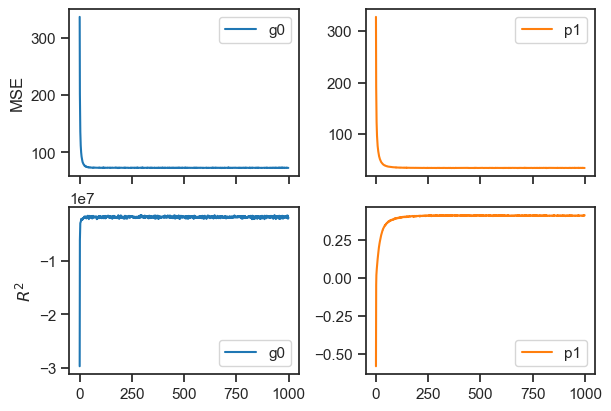

In [35]:
fig, axes = create_figure(2, len(tr.model.layers), sharex='all')

for i, name in enumerate(tr.model.layers):
    axes[0, i].plot(mse[name], color=f'C{i}', label=name)
    axes[1, i].plot(r2[name], color=f'C{i}', label=name)
axes[0, 0].set(ylabel='MSE')
axes[1, 0].set(ylabel=r'$R^2$')
add_legend(axes)
plt.show()

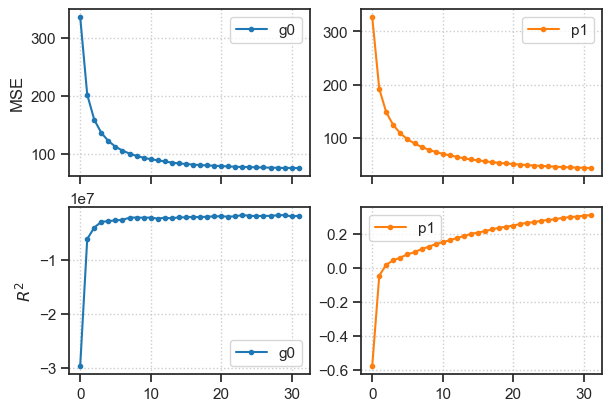

In [36]:
fig, axes = create_figure(2, len(tr.model.layers), sharex='all')

intvl = range(32)

for i, name in enumerate(tr.model.layers):
    axes[0, i].plot(mse[name][intvl], marker='.', color=f'C{i}', label=name)
    axes[1, i].plot(r2[name][intvl], marker='.', color=f'C{i}', label=name)
axes[0, 0].set(ylabel='MSE')
axes[1, 0].set(ylabel=r'$R^2$')
add_legend(axes)
add_grid(axes)
plt.show()

In [37]:
r2['p1'][-10:]

array([0.40821403, 0.40598226, 0.40893257, 0.40678185, 0.40844479,
       0.40928507, 0.40839326, 0.40725321, 0.40788138, 0.410909  ])

In [38]:
# order: high contrast
var = tonp(torch.var(true, dim=1))
order = np.argsort(var)[::-1]

In [39]:
def _reshape_transpose(x):
    x2p = tonp(x).reshape(tr.model.cfg.input_sz)
    x2p = np.transpose(x2p, (1, 2, 0))
    return x2p


def _plot_selected_samples(select_from=None, ncols=20, seed=0):
    rng = get_rng(seed)

    nrows = 6
    fig, axes = create_figure(nrows, ncols, (1 * ncols + 0.1, 1 * nrows), 'all', 'all')

    select_from = order[:200] if select_from is None else select_from
    selected_ids = rng.choice(select_from, size=ncols, replace=False)

    for i in range(ncols):
        idx = selected_ids[i]
        axes[0, i].imshow(_reshape_transpose(true[idx]), cmap='Greys_r')
        axes[1, i].imshow(_reshape_transpose(pred['g0'][idx]), cmap='Greys_r')
        axes[2, i].imshow(_reshape_transpose(error['g0'][idx]), cmap='Greys_r')
        # axes[3, i].imshow(tonp(whitened[idx]).reshape(16, 16), cmap='Greys_r')
        axes[4, i].imshow(_reshape_transpose(pred['p1'][idx]), cmap='Greys_r')
        axes[5, i].imshow(_reshape_transpose(error['p1'][idx]), cmap='Greys_r')

    axes[0, 0].set_ylabel('img', fontsize=15)
    axes[1, 0].set_ylabel('pred\n(retina)', fontsize=15)
    axes[2, 0].set_ylabel('error\n(retina)', fontsize=15)
    axes[3, 0].set_ylabel('whitened', fontsize=15)
    axes[4, 0].set_ylabel('pred\n(v1)', fontsize=15)
    axes[5, 0].set_ylabel('error\n(v1)', fontsize=15)

    remove_ticks(axes, False)
    plt.show()

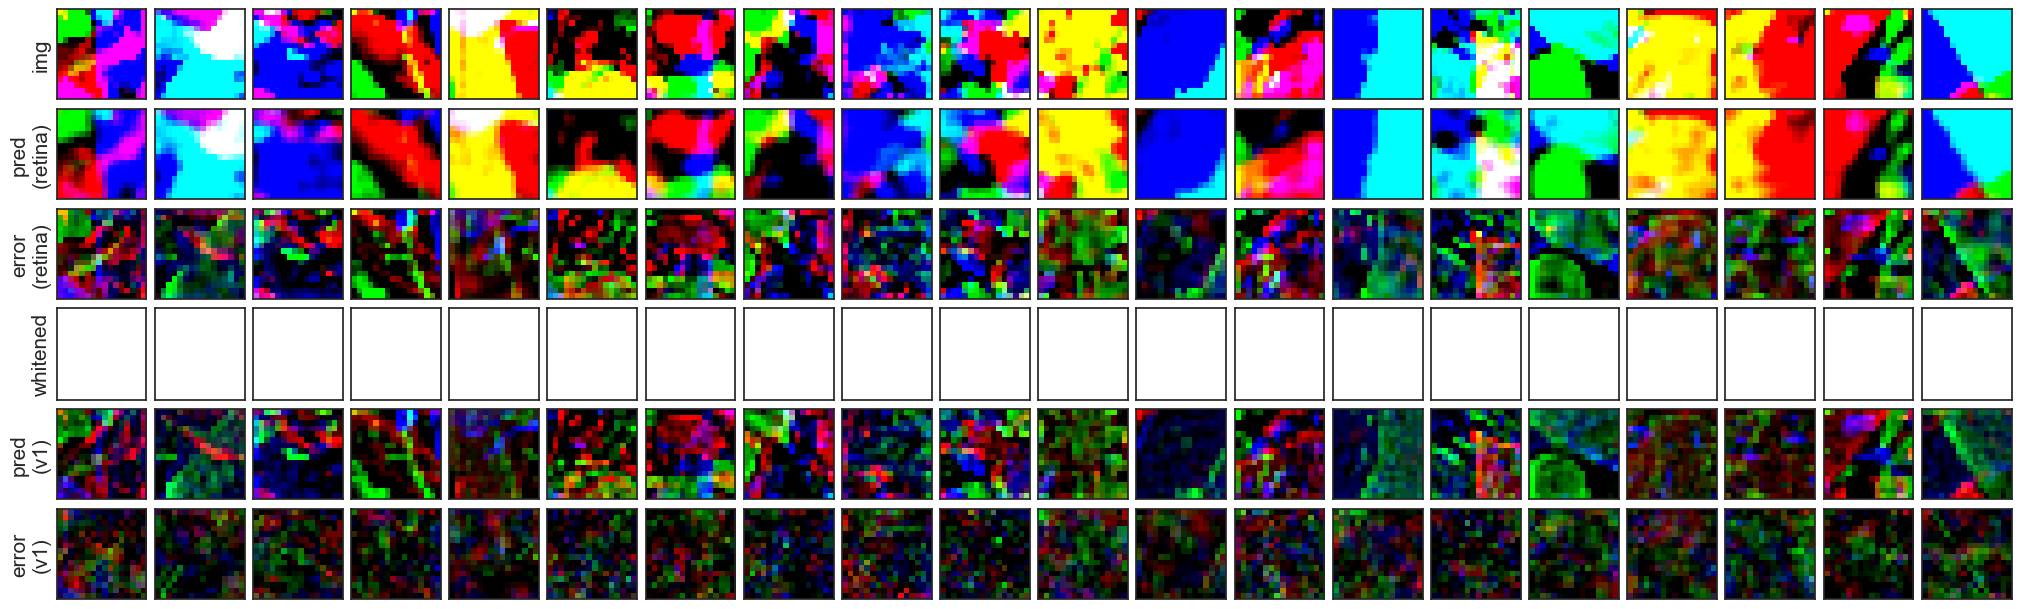

In [40]:
_plot_selected_samples()

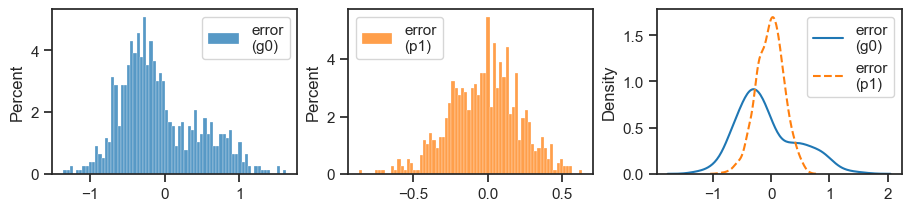

In [41]:
fig, axes = create_figure(1, len(error) + 1)

num = -1

for i, (name, x2p) in enumerate(error.items()):
    sns.histplot(tonp(x2p[num].ravel()), stat='percent', bins=70, color=f'C{i}', label=f'error\n({name})', ax=axes[i])
    sns.kdeplot(tonp(x2p[num].ravel()), color=f'C{i}', label=f'error\n({name})', ls='-' if i % 2 == 0 else '--', ax=axes[-1])
add_legend(axes)
plt.show()

In [42]:
for name, z in samples.items():
    life, pop, portions = sparse_score(z, cutoff=0.01)
    print(f"layer: {name}\nlifetime: {life.mean().item():0.3f}\nportions:{portions}\n")

layer: g0
lifetime: 0.119
portions:{'0': 34.4, '1': 63.1, '2': 1.8, '3': 0.6, '4+': 0}

layer: p1
lifetime: 0.865
portions:{'0': 75.6, '1': 7.3, '2': 4.8, '3': 3.4, '4': 2.4, '5': 1.7, '6': 1.2, '7': 0.9, '8+': 2.7}

In [43]:
print(tr.model.layers['p1'].n_exp)
tr.model.layers['p1'].posterior.n_exp

tensor([ 17,  19,  22,  24,  27,  31,  38,  47,  57,  66,  75,  82,  88,  92,
         95,  97,  99, 101, 102, 103, 104, 104, 104, 105, 106, 107, 108, 109,
        109, 109, 110, 111, 112, 113, 113, 114, 114, 115, 115, 116, 115, 115,
        115, 115, 116, 115, 116, 117, 117, 117, 117, 117, 117, 118, 117, 117,
        117, 117, 118, 119, 121, 121, 121, 121], device='cuda:0',
       dtype=torch.int32)

132

## White noise

In [30]:
from analysis.sta import perform_sta_analysis
from utils.animation import show_movie

In [31]:
sta = perform_sta_analysis(tr, t_total=1, n_trials=100, batch_size=10_000)

100%|█████████████████████████████████████████| 100/100 [47:10<00:00, 28.31s/it]


In [32]:
n_lags = 80
s_kers = {
    name: np_nans((len(sta_array), 16, 16))
    for name, sta_array in sta.items()
}
t_kers = {
    name: np_nans((len(sta_array), n_lags + 1))
    for name, sta_array in sta.items()
}

for name, sta_array in sta.items():
    for i in range(len(sta_array)):
        uu, ss, vvh = torch.linalg.svd(
            sta_array[i], full_matrices=False)
    
        s_kers[name][i] = tonp(vvh[0]).reshape(16, 16)
        t_kers[name][i] = tonp(uu[:, 0])

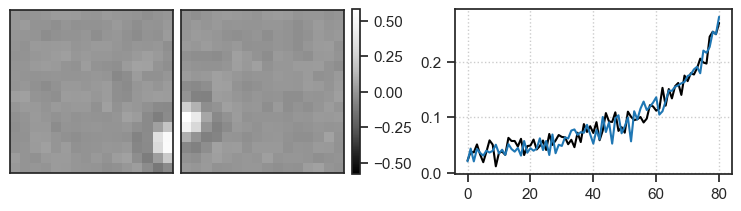

In [33]:
name = 'g0'
i, j = 44, 68
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

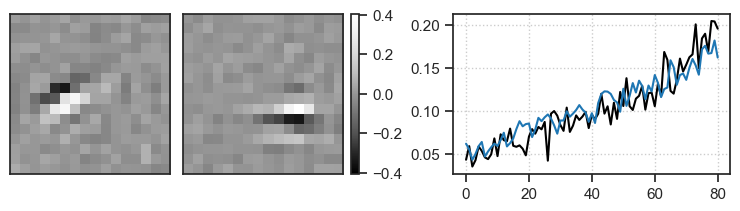

In [34]:
name = 'p1'
i, j = 57, 25
vminmax = np.abs(s_kers[name][[i, j]]).max()

fig, axes = create_figure(1, 3, (7.3, 2.0), width_ratios=[1, 1, 1.7])

im = axes[0].imshow(s_kers[name][i], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
im = axes[1].imshow(s_kers[name][j], cmap='Greys_r', vmin=-vminmax, vmax=vminmax)
plt.colorbar(im, ax=axes[1])

axes[2].plot(t_kers[name][i], color='k')
axes[2].plot(t_kers[name][j], color='C0')
axes[2].grid()

remove_ticks(axes[:2], False)
plt.show()

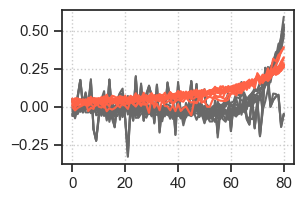

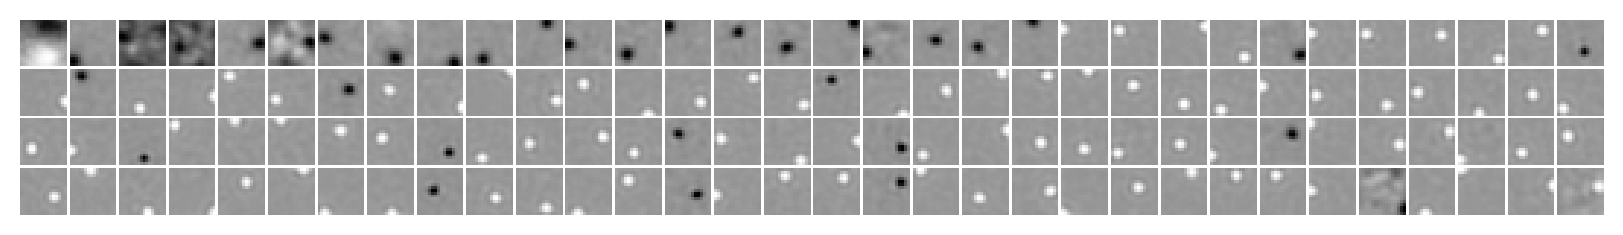

In [35]:
order = np.argsort(t_kers['g0'][:, 70])

plot(t_kers['g0'][order][:13].T, color='dimgrey');
plot(t_kers['g0'][order][-13:].T, color='tomato');
plt.grid()
plt.show()

_ = tr.model.show('g0', order=order, nrows=4, method='abs-max')